In [1]:
import sys
sys.path.append(r'c:\afstuderen\python_projects\beroepsproduct')


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
import numpy as np
import pastas as ps
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

hpd.util.get_color_logger("INFO")

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [3]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [4]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)
gw = oc.obs["GMW000000038036001"]

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 2
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 2/2 [00:20<00:00, 10.38s/it]


In [5]:
tmin = START_DATE
tmax = END_DATE

precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw.x, gw.y),
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw.x, gw.y),
    meteo_var="EV24",
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)
opp_water = pd.read_csv(
    '20260324-2678.csv',
    sep=';',
    dtype=str  # Ensure all columns are read as strings for safe datetime parsing
)

# Combine date and time columns to create a datetime index
opp_water['datetime'] = pd.to_datetime(
    opp_water['WAARNEMINGDATUM'] + ' ' + opp_water['WAARNEMINGTIJD'],
    errors='coerce'
)
opp_water = opp_water.set_index('datetime')
opp_water = opp_water.sort_index()
opp_water = opp_water.loc[opp_water.index.dropna()]

# Convert NUMERIEKEWAARDE to float meters
opp_water["NUMERIEKEWAARDE"] = pd.to_numeric(opp_water["NUMERIEKEWAARDE"], errors="coerce") / 100

INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (88539.8036558846, 433899.86505311105) and meteovariable RH
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (88539.8036558846, 433899.86505311105) and meteovariable EV24


INFO:pastas.timeseries._fill_before:Time Series 'RH' was extended in the past to 2013-01-03 01:00:00 with the mean value (0.0029) of the time series.
INFO:pastas.timeseries._fill_before:Time Series 'EV24' was extended in the past to 2013-01-03 01:00:00 with the mean value (0.0017) of the time series.
INFO:pastas.model.residuals:There are observations between the simulation time steps. Linear interpolation between simulated values is used.
Fit report groundwater              Fit Statistics
nfev     30                     EVP          80.13
nobs     534                    R2            0.79
noise    True                   RMSE          0.18
tmin     2023-01-01 00:00:00    AICc      -3378.61
tmax     2024-12-31 00:00:00    BIC       -3357.32
freq     D                      Obj           0.47
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.        Yes
solver   LeastSquares           weights        Yes

Parameters (5 optimized)
                optim

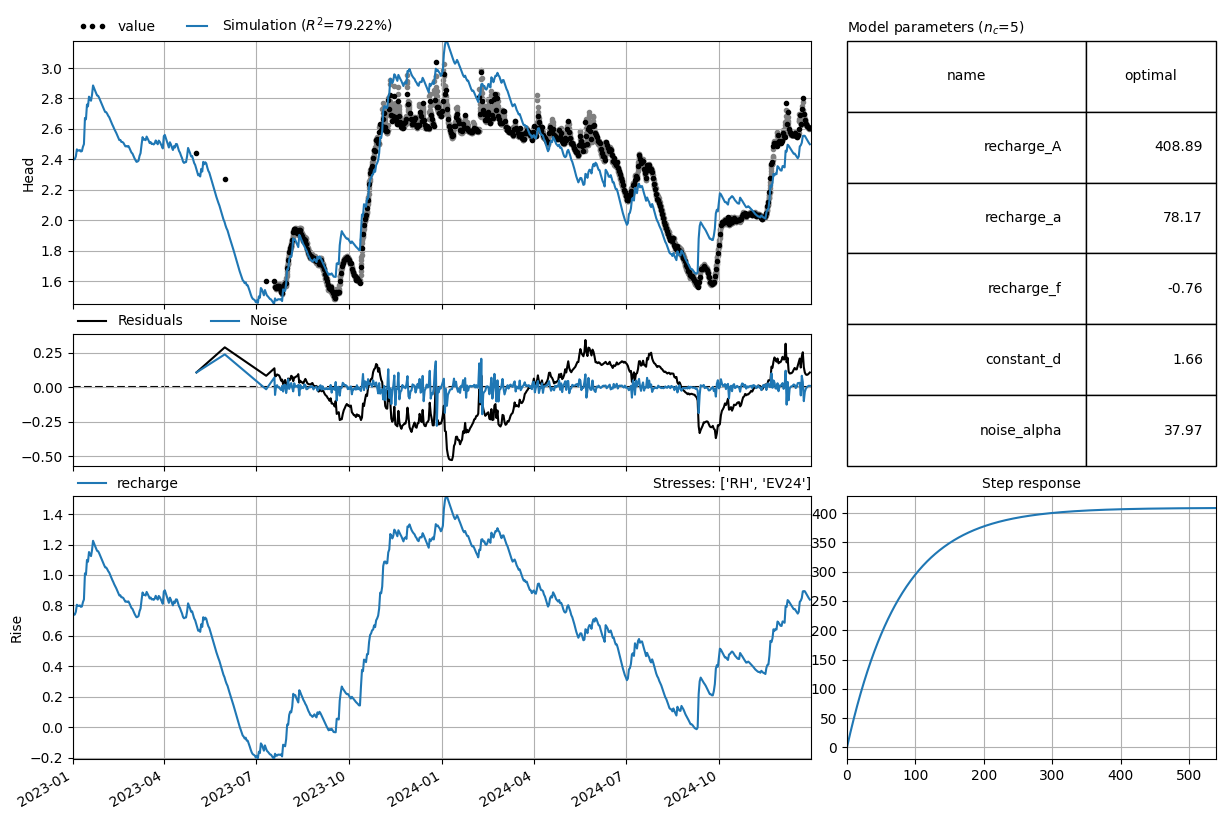

In [6]:
ml = ps.Model(gw["value"].dropna(), name="groundwater")
ml.add_noisemodel(ps.ArNoiseModel())

sm = ps.RechargeModel(precipitation["RH"], evaporation["EV24"], rfunc=ps.Exponential(), name="recharge")
ml.add_stressmodel(sm)

ml.solve(tmin=tmin, tmax=tmax)
ml.plots.results(figsize=(12, 8));

INFO:pastas.timeseries._fill_nan:Time Series 'NUMERIEKEWAARDE': 430 nan-value(s) was/were found and filled with: interpolate.
INFO:pastas.timeseries._fill_nan:Time Series 'NUMERIEKEWAARDE': 430 nan-value(s) was/were found and filled with: interpolate.
INFO:pastas.timeseries._fill_nan:Time Series 'NUMERIEKEWAARDE': 430 nan-value(s) was/were found and filled with: interpolate.
INFO:pastas.timeseries._fill_before:Time Series 'NUMERIEKEWAARDE' was extended in the past to 2013-01-03 01:00:00 with the mean value (0.36) of the time series.
INFO:pastas.timeseries._fill_after:Time Series 'NUMERIEKEWAARDE' was extended in the future to 2024-12-30 01:00:00 with the mean value (0.36) of the time series.
INFO:pastas.model.residuals:There are observations between the simulation time steps. Linear interpolation between simulated values is used.
Fit report groundwater              Fit Statistics
nfev     32                     EVP          80.20
nobs     534                    R2            0.79
noise

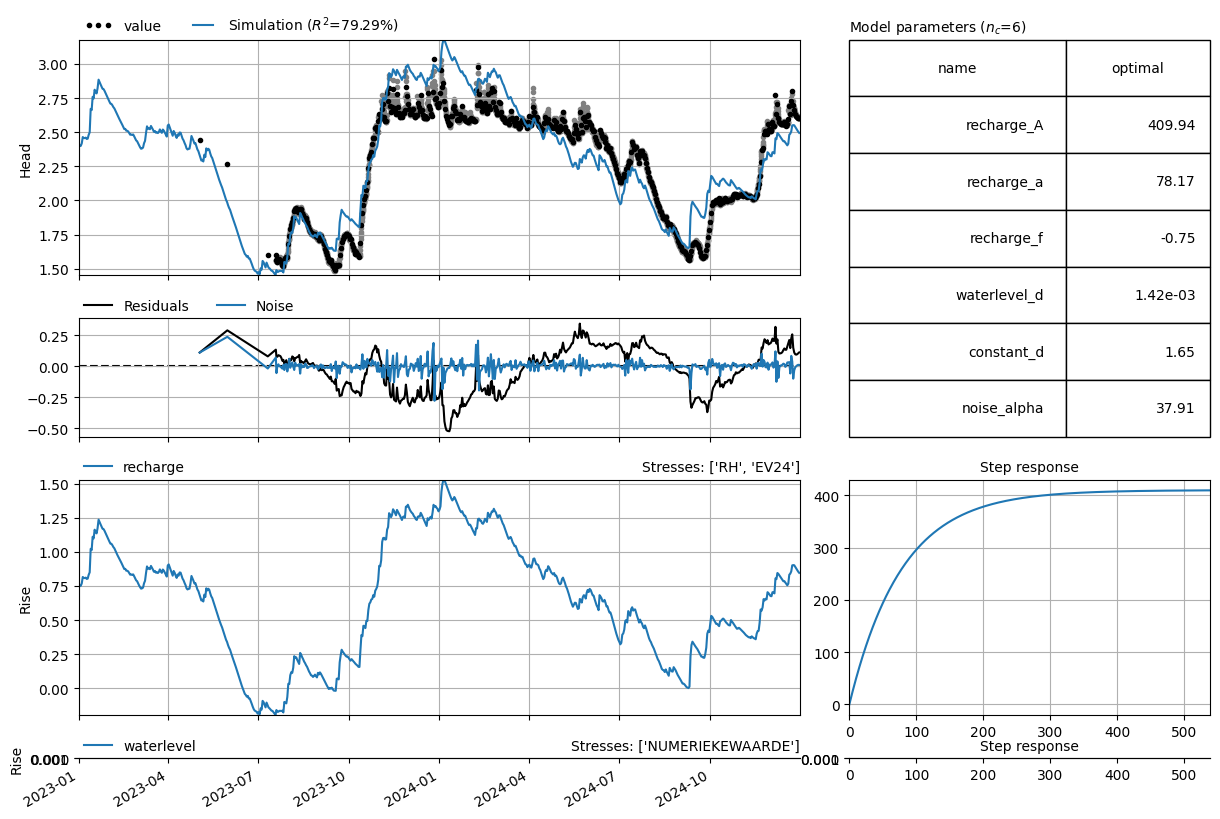

In [7]:
# Resample to daily averages and align with KNMI daily timestamps
opp_water_daily = opp_water["NUMERIEKEWAARDE"].resample("D").mean()
opp_water_daily.index = opp_water_daily.index + pd.Timedelta(hours=1)

w = ps.StressModel(opp_water_daily, rfunc=ps.One(), name="waterlevel", settings="waterlevel")
ml.add_stressmodel(w)
ml.solve(tmin=tmin, tmax=tmax)
axes = ml.plots.results(figsize=(12, 8))
axes[-1].set_xlim(0, 20);  # By default, the axes between responses are shared.

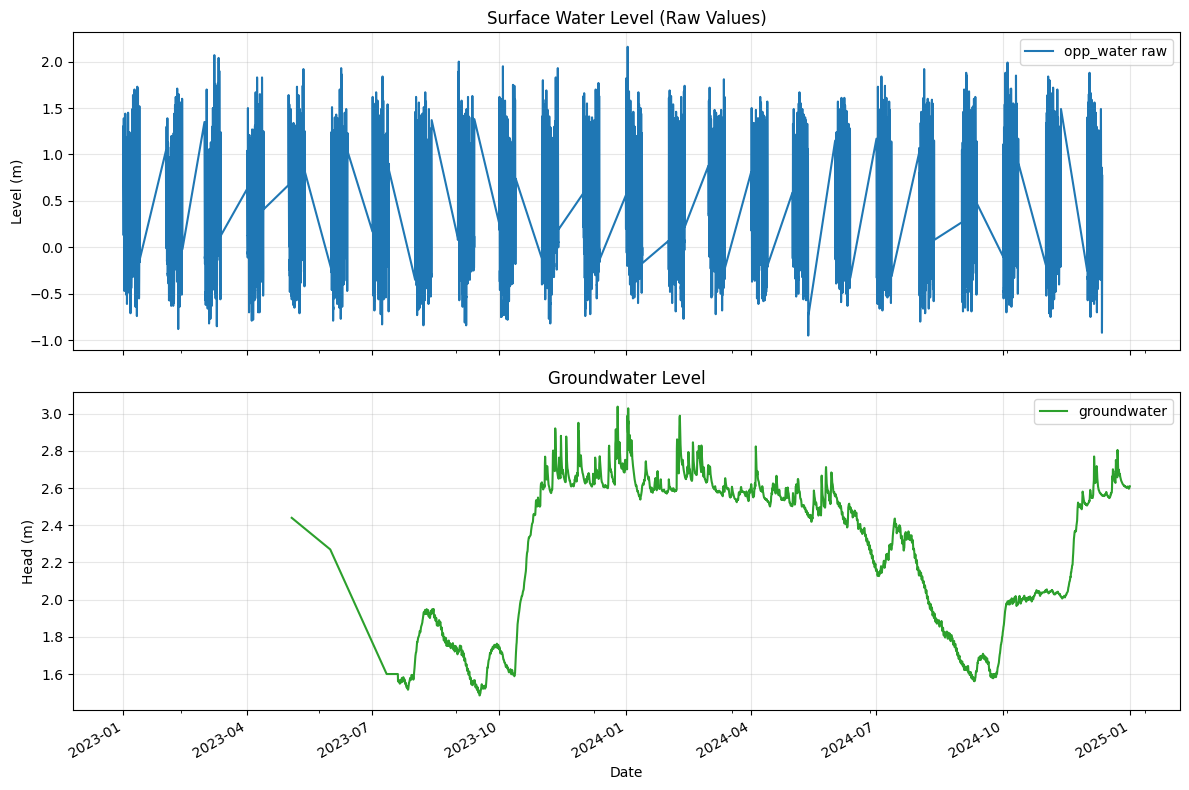

In [11]:
opp_water_raw_period = opp_water.loc[tmin:tmax, "NUMERIEKEWAARDE"].dropna()
gw_period = gw["value"].dropna().loc[tmin:tmax]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

opp_water_raw_period.plot(ax=axes[0], color="tab:blue", label="opp_water raw")
axes[0].set_title("Surface Water Level (Raw Values)")
axes[0].set_ylabel("Level (m)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

gw_period.plot(ax=axes[1], color="tab:green", label="groundwater")
axes[1].set_title("Groundwater Level")
axes[1].set_ylabel("Head (m)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()